
### О ЛР:

- scikit-learn & decision trees
- Coding decision tree & Categorical features


----

#### Самостоятельная оценка результатов

Для удобства проверки, исходя из набора решенных задач, посчитайте свою максимальную оценку.

**Оценка**:

***DeadLine - 21.05.2024 23:59***

### Формат сдачи
Задания сдаются через lms. Вы прикрепляете **ССЫЛКУ НА ПУБЛИЧНЫЙ РЕПОЗИТОРИЙ**, где выполнено ваше задание. Иначе задание не проверяется.




### Оценивание и штрафы


Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 5 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты не могут получить за него больше 0 баллов.

Неэффективная реализация кода может негативно отразиться на оценке.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

sns.set(style="whitegrid")

import warnings

warnings.filterwarnings("ignore")

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=0.8,
        random_state=3,
        n_redundant=0,
    ),
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

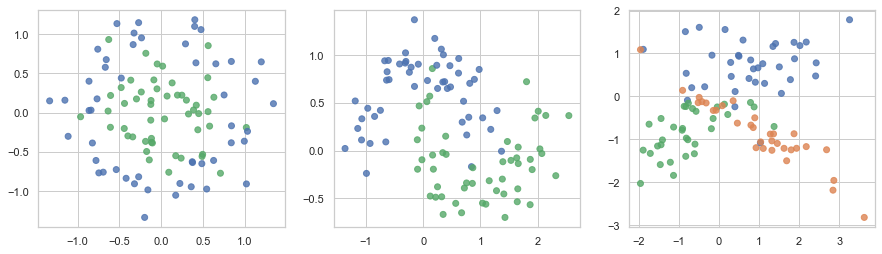

In [5]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=0.8)

__Задание 1. [0.5 балла]__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [4]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
    )
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=cmap,
        alpha=0.7,
        edgecolors=np.array(palette)[y],
        linewidths=2,
    )
    plt.show();

In [5]:
from sklearn.linear_model import LinearRegression

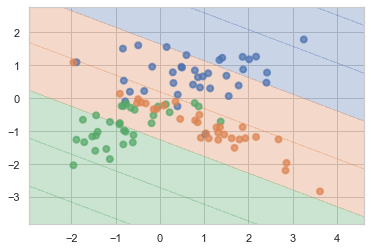

In [7]:
# Пример:
from sklearn.linear_model import LinearRegression

X, y = datasets[2]
lr = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [6]:
from sklearn.metrics import accuracy_score

0 --- Train Acc: 1.00, Test Acc: 0.40


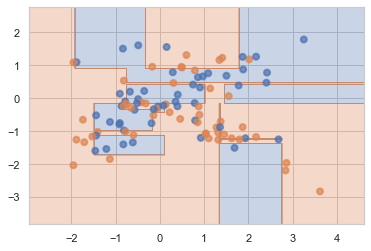

1 --- Train Acc: 1.00, Test Acc: 0.40


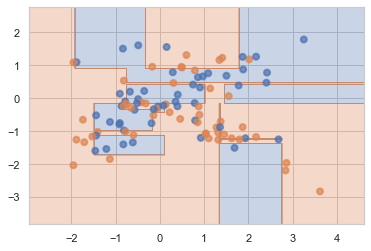

2 --- Train Acc: 1.00, Test Acc: 0.70


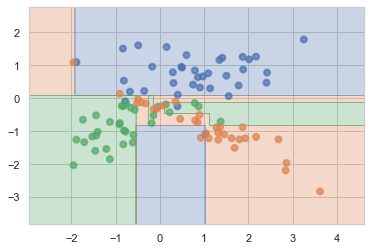

In [ ]:
for i, (x, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    print(f"{i} --- Train Acc: {acc_train:.2f}, Test Acc: {acc_test:.2f}")
    plot_surface(clf, X, y)

__Ответ:__ Да, переобучились очень сильно (особенно moons и circles)

__Задание 2. [0.75 балла]__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

circles
circles --- depth=2 & min_leaf=1
Train Acc: 0.70 | Test Acc: 0.40


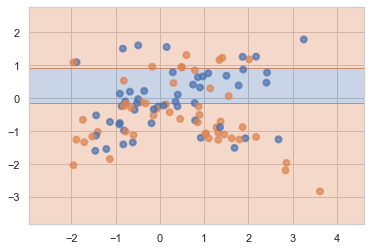

circles --- depth=2 & min_leaf=5
Train Acc: 0.70 | Test Acc: 0.40


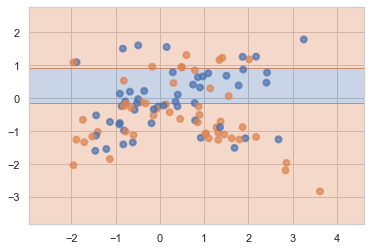

circles --- depth=2 & min_leaf=10
Train Acc: 0.70 | Test Acc: 0.40


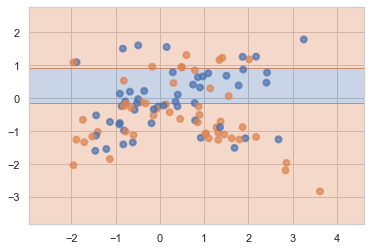

circles --- depth=4 & min_leaf=1
Train Acc: 0.85 | Test Acc: 0.45


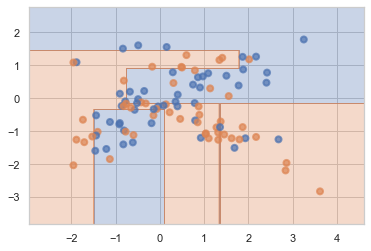

circles --- depth=4 & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


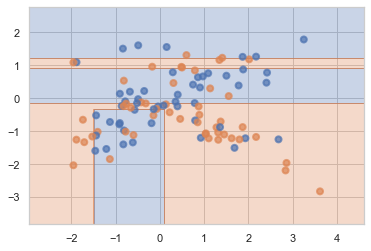

circles --- depth=4 & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


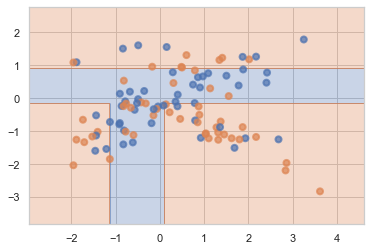

circles --- depth=6 & min_leaf=1
Train Acc: 0.93 | Test Acc: 0.45


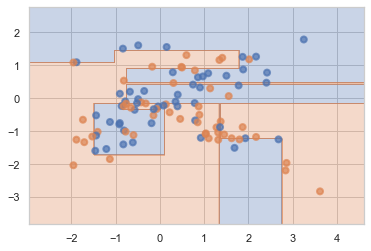

circles --- depth=6 & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


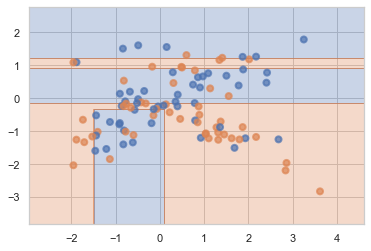

circles --- depth=6 & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


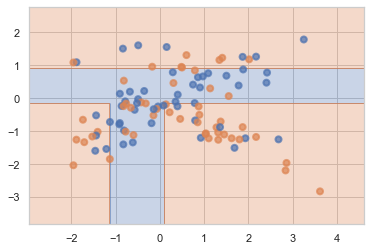

circles --- depth=None & min_leaf=1
Train Acc: 1.00 | Test Acc: 0.40


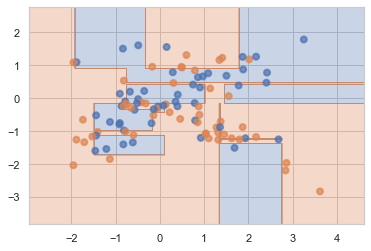

circles --- depth=None & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


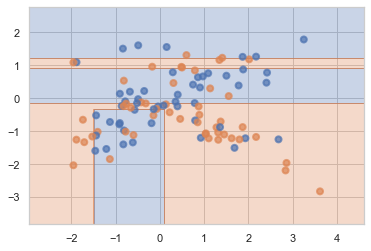

circles --- depth=None & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


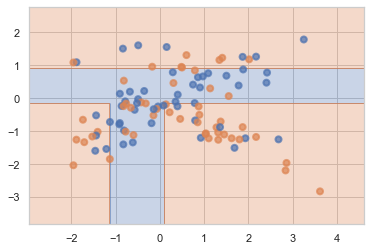

moons
moons --- depth=2 & min_leaf=1
Train Acc: 0.70 | Test Acc: 0.40


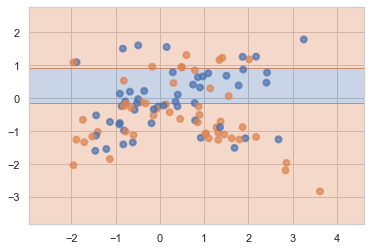

moons --- depth=2 & min_leaf=5
Train Acc: 0.70 | Test Acc: 0.40


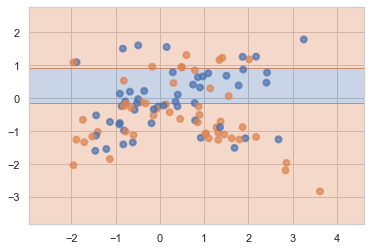

moons --- depth=2 & min_leaf=10
Train Acc: 0.70 | Test Acc: 0.40


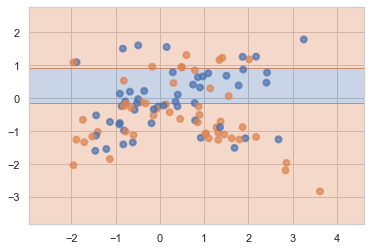

moons --- depth=4 & min_leaf=1
Train Acc: 0.85 | Test Acc: 0.45


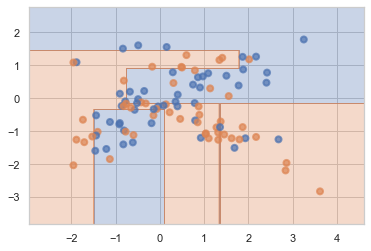

moons --- depth=4 & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


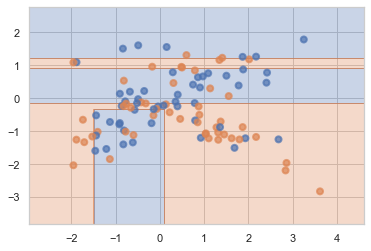

moons --- depth=4 & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


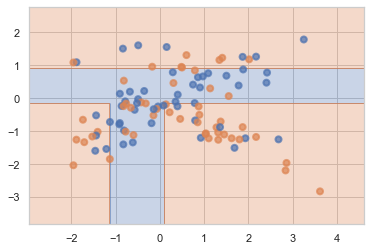

moons --- depth=6 & min_leaf=1
Train Acc: 0.93 | Test Acc: 0.45


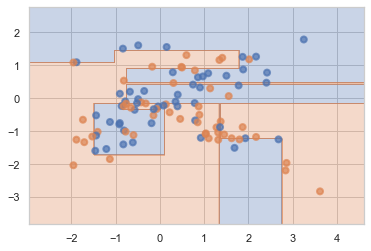

moons --- depth=6 & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


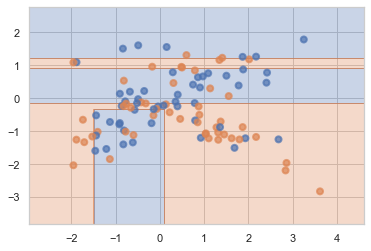

moons --- depth=6 & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


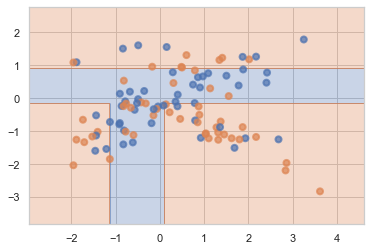

moons --- depth=None & min_leaf=1
Train Acc: 1.00 | Test Acc: 0.40


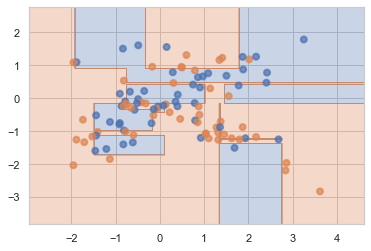

moons --- depth=None & min_leaf=5
Train Acc: 0.80 | Test Acc: 0.60


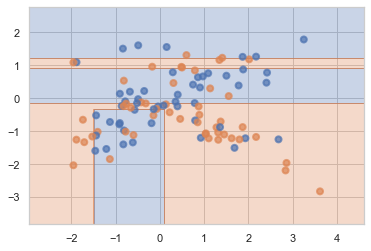

moons --- depth=None & min_leaf=10
Train Acc: 0.72 | Test Acc: 0.50


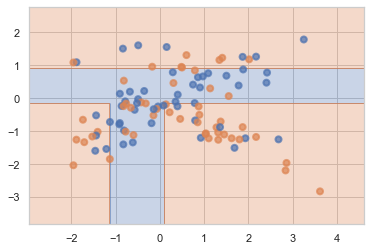

make_class
make_class --- depth=2 & min_leaf=1
Train Acc: 0.90 | Test Acc: 0.75


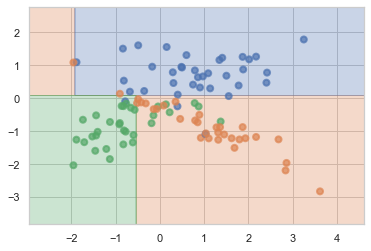

make_class --- depth=2 & min_leaf=5
Train Acc: 0.89 | Test Acc: 0.75


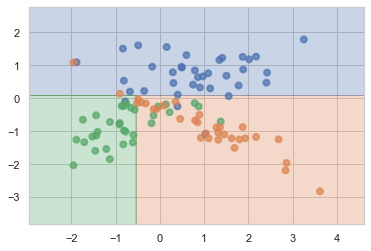

make_class --- depth=2 & min_leaf=10
Train Acc: 0.89 | Test Acc: 0.75


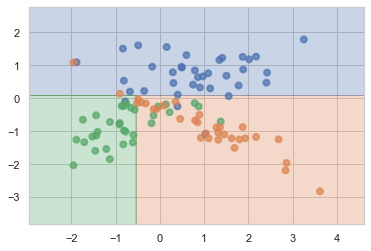

make_class --- depth=4 & min_leaf=1
Train Acc: 0.91 | Test Acc: 0.70


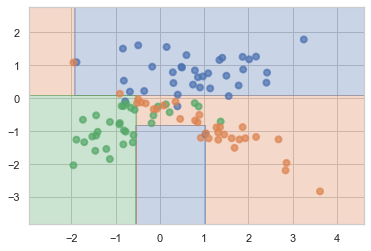

make_class --- depth=4 & min_leaf=5
Train Acc: 0.90 | Test Acc: 0.70


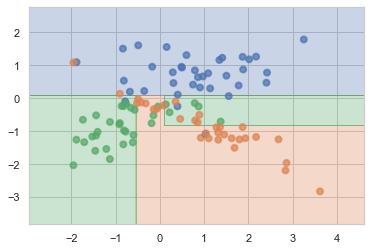

make_class --- depth=4 & min_leaf=10
Train Acc: 0.89 | Test Acc: 0.75


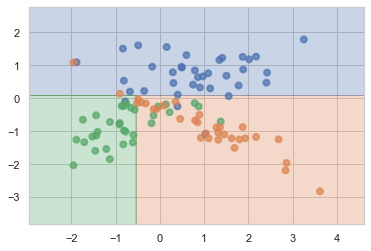

make_class --- depth=6 & min_leaf=1
Train Acc: 0.95 | Test Acc: 0.65


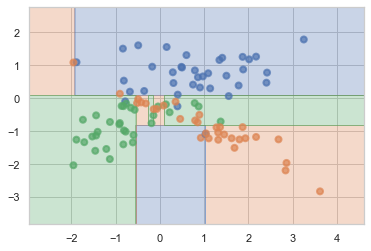

make_class --- depth=6 & min_leaf=5
Train Acc: 0.90 | Test Acc: 0.70


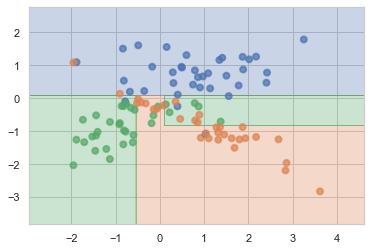

make_class --- depth=6 & min_leaf=10
Train Acc: 0.89 | Test Acc: 0.75


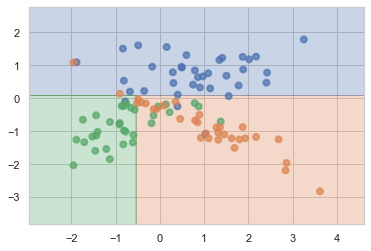

make_class --- depth=None & min_leaf=1
Train Acc: 1.00 | Test Acc: 0.70


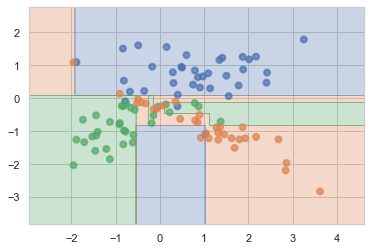

make_class --- depth=None & min_leaf=5
Train Acc: 0.90 | Test Acc: 0.70


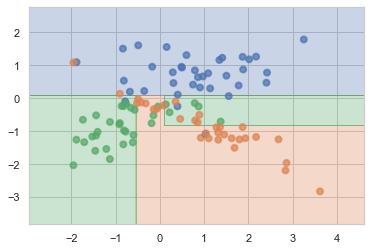

make_class --- depth=None & min_leaf=10
Train Acc: 0.89 | Test Acc: 0.75


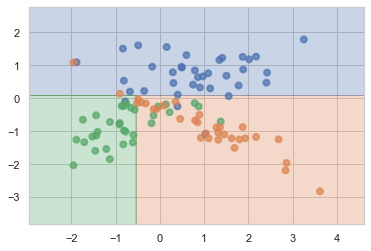

In [13]:
depths = [2, 4, 6, None]
min_samples = [1, 5, 10]
names = ['circles', 'moons', 'make_class']
results = []

# Обработка каждого датасета
for i, (x, y) in enumerate(datasets):
    print(f"{names[i]}")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for max_depth in depths:
        for min_samples_leaf in min_samples:
            clf = DecisionTreeClassifier(
                max_depth=max_depth, 
                min_samples_leaf=min_samples_leaf, 
                random_state=42
            )
            clf.fit(X_train, y_train)
            train_acc = accuracy_score(y_train, clf.predict(X_train))
            test_acc = accuracy_score(y_test, clf.predict(X_test))
            title = (f"{names[i]} --- depth={max_depth} & min_leaf={min_samples_leaf}\n"
                     f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
            print(title)
            plot_surface(clf, X, y)

            results.append({
                'dataset': names[i],
                'max_depth': max_depth if max_depth is not None else 'None',
                'min_samples_leaf': min_samples_leaf,
                'train_acc': train_acc,
                'test_acc': test_acc
            })

In [14]:
pd.DataFrame(results)

,dataset,max_depth,min_samples_leaf,train_acc,test_acc
0,circles,2,1,0.7000,0.40
1,circles,2,5,0.7000,0.40
2,circles,2,10,0.7000,0.40
3,circles,4,1,0.8500,0.45
4,circles,4,5,0.8000,0.60
5,circles,4,10,0.7250,0.50
6,circles,6,1,0.9250,0.45
7,circles,6,5,0.8000,0.60
8,circles,6,10,0.7250,0.50
9,circles,None,1,1.0000,0.40


__Ответ:__ форма разделяющей поыерхности заметно усложняется по мере уведичения глубины дерева. При этом увеличение минимального количества элементов в листе упрощает форму обучающей выборки. Оно и логично, большая глубина + маленький min_leaf позволяют сильно дробить результат, что приводит к уменьшению обобщающей способности и сильному переобучению.
До датасетов moons и circles характерно сильное переобучение для параметров с глубокими деревьями и маленьким количеством элементов в листе. Видимо поверхность достаточно сложно разделима и дерево сильно подстроилось под обучающую выборку. В make_class можно линейно легко разделить поверхность, поэтому и дереву сложнее переобучиться на тренировочной выборке

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. [0.75 балл]__

Реализуйте функцию `find_best_split` из модуля `tree_code.py`

In [6]:
# Готово

__Задание 4. [0.25 балла]__

`students.csv` - это преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). Первые пять столбцов содержат признаки каждого объекта, а последний столбец — целевую переменную (класс: 0 или 1). Нужно построить график, который на одном изображении отобразит пять кривых "порог — значение критерия Джини" для всех пяти признаков. Кроме того, стоит отдельно визуализировать scatter-графики "значение признака — класс" для каждого из пяти признаков.

Это нужно и для выявления значимости признаков, и для пороговых значений. Да и глазу приятно

In [8]:
df = pd.read_csv('students.csv')

In [9]:
df.head(1)

,STG,SCG,STR,LPR,PEG,UNS
0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STG     258 non-null    float64
 1   SCG     258 non-null    float64
 2   STR     258 non-null    float64
 3   LPR     258 non-null    float64
 4   PEG     258 non-null    float64
 5   UNS     258 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 12.2 KB


In [11]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

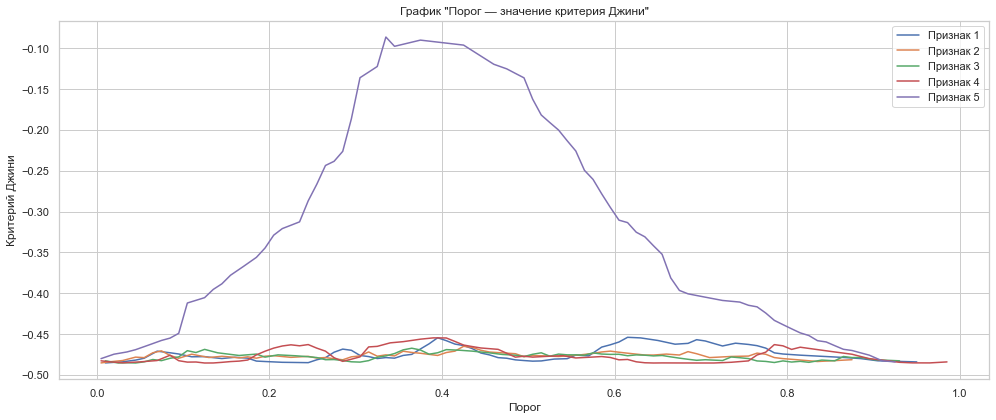

In [13]:
import matplotlib.pyplot as plt
from tree_code import find_best_split  # если у тебя функция в этом модуле

plt.figure(figsize=(14, 6))

for i in range(5):
    feature_vector = X[:, i]
    thresholds, ginis, threshold_best, gini_best = find_best_split(feature_vector, y)
    
    plt.plot(thresholds, ginis, label=f'Признак {i+1}')
    
plt.xlabel('Порог')
plt.ylabel('Критерий Джини')
plt.title('График "Порог — значение критерия Джини"')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


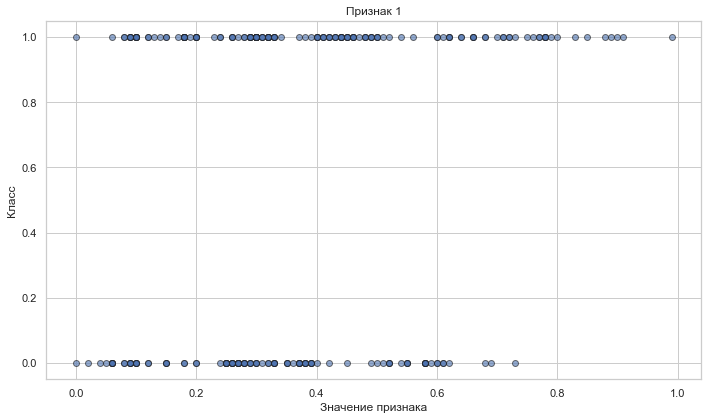

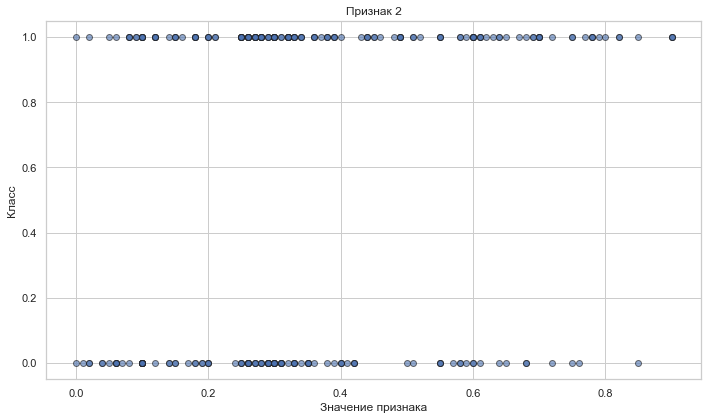

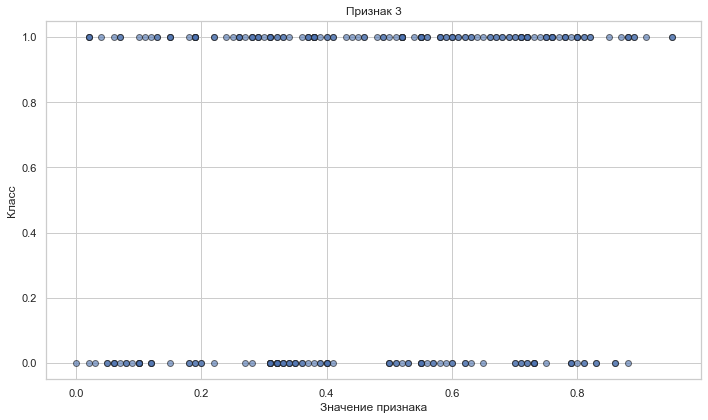

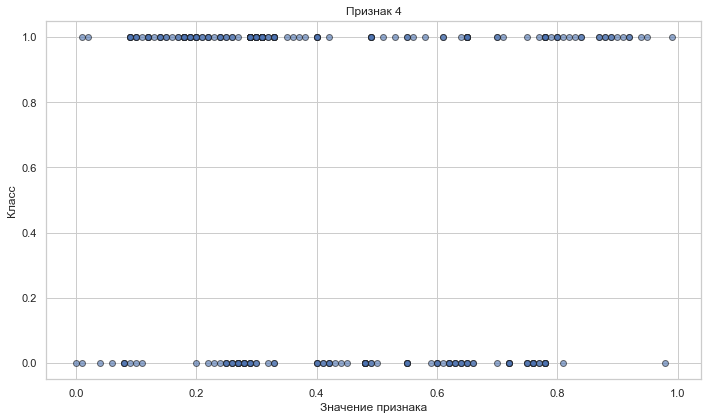

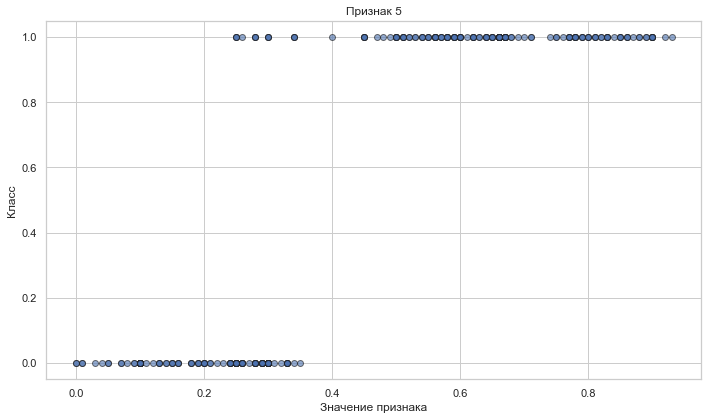

In [17]:
for i in range(5):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, i], y, alpha=0.6, edgecolors='k')
    plt.title(f'Признак {i+1}')
    plt.xlabel('Значение признака')
    plt.ylabel('Класс')
    plt.tight_layout()
    plt.show()

__Задание 5. [0.25 балла]__

На основании кривых критерия Джини, по какому признаку стоит разделить выборку на два поддерева? Совпадает ли этот выбор с визуальной оценкой scatter-графиков? Как бы вы описали вид кривой для "хороших" признаков, по которым выборка делится почти идеально, и чем кривые таких признаков отличаются от кривых признаков, по которым разделение практически невозможно?

**Ответ:** Ого, задание, где ответ очевиден. Самом собой это пятый признак. На первом графике у него явно выраженный максимум и самое большое значение критерия Джини. Скаттер плоты только подтверждают этот вывод, так как явно часть признаков у нас слева, а вторая часть справа, в то время как для  других признаков нет такого явного разделения.

Идеальные кривые - кривые с явным максимумом, плохие - кривые равномерные, получается нет у нас никакого хорошего разделяющего значения. Ну и на хороших скаттерах можно провести линию разделения, где будут слева и справа признаки, а на плохих все смешано

In [31]:
# готово

__Задание 6. [0.75 балла].__

Разберитесь с уже написанным кодом в классе DecisionTree модуля tree_code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».




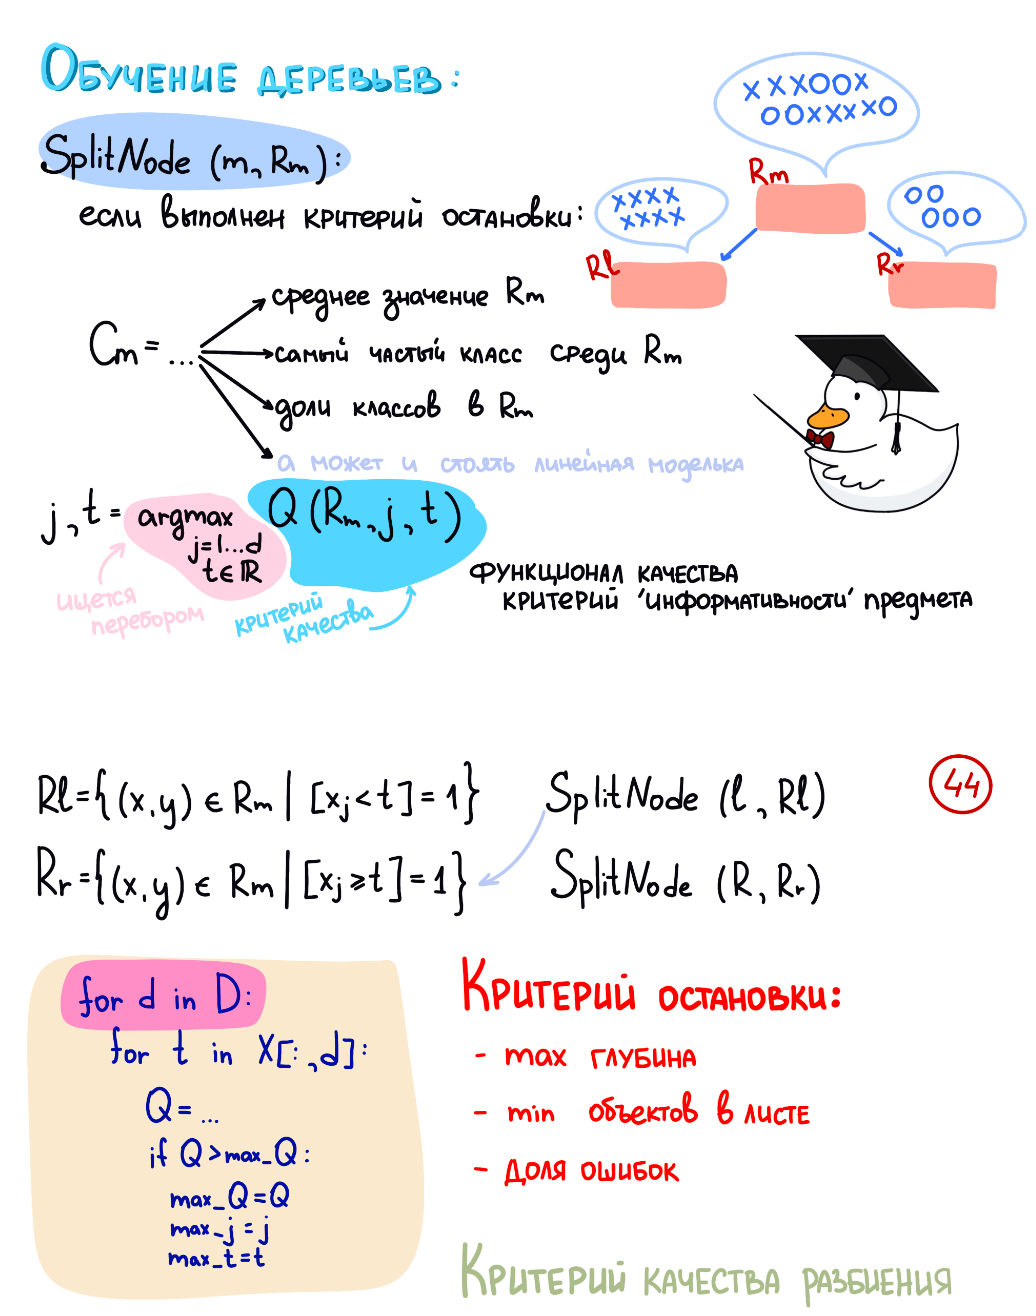

__Задание 7. [0.25 балла]__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно открыть` agaricus-lepiota.data`, прочитать ее с помощью pandas (не забудьте про `agaricus-lepiota.names`), применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

_SPOILER: У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево_

In [77]:
from tree_code import DecisionTree
from sklearn.preprocessing import LabelEncoder
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
path = "agaricus-lepiota.data"
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 
    'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type',
    'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]
df = pd.read_csv(path, header=None, names=column_names)

In [79]:
df.head(1)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [81]:
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [82]:
X = df.drop(columns='class').values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [83]:
tree = DecisionTree(feature_types=['categorical'] * X.shape[1])
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


__Задание 8. [1 балл]__

Загрузите следующие наборы данных, предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

**Задача**:

Закодировать категориальные признаки в наборе данных с использованием `LabelEncoder`. Затем, применив `cross_val_score` (cv=10), оценить метрику accuracy для следующих алгоритмов:

1. **DecisionTree**, обрабатывающий все признаки как вещественные.
2. **DecisionTree**, обрабатывающий все признаки как категориальные.
3. **DecisionTree**, обрабатывающий все признаки как вещественные + one-hot encoding всех признаков.
4. **DecisionTreeClassifier** из `sklearn`.

**Инструкция**:
1. Закодировать категориальные признаки с помощью `LabelEncoder`.
2. Оценить accuracy, используя `cross_val_score` (cv=10) и `scoring=make_scorer(accuracy_score)`.
3. Если позволяет память, установить параметр `sparse=False` в `OneHotEncoder`.
4. Результаты сохранить в `pd.DataFrame` (по строкам — наборы данных, по столбцам — алгоритмы).

**Рекомендации**:
- Для вычисления точности используйте `scoring=make_scorer(accuracy_score)` из `sklearn.metrics`.

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import StratifiedKFold

In [76]:
#  cross_val_score похоже только к sklearn классам работает. Наш легко не вошел, так что пришлось пойти другим путем

In [ ]:
def process_and_evaluate_data(X, y):
    results = {}
    X_np = X.to_numpy() if hasattr(X, "to_numpy") else np.array(X)
    y_np = np.array(y)

    n_features = X_np.shape[1]

    # 1. **DecisionTree**, обрабатывающий все признаки как вещественные.
    feature_types_real = ["real"] * n_features
    model = DecisionTree(feature_types=feature_types_real)
    scores = []
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    for train_idx, test_idx in skf.split(X_np, y_np):
        model.fit(X_np[train_idx], y_np[train_idx])
        preds = model.predict(X_np[test_idx])
        scores.append(accuracy_score(y_np[test_idx], preds))
    results["DecisionTree (real features)"] = np.mean(scores)

    # 2. **DecisionTree**, обрабатывающий все признаки как категориальные.
    feature_types_cat = ["categorical"] * n_features
    model = DecisionTree(feature_types=feature_types_cat)
    scores = []
    for train_idx, test_idx in skf.split(X_np, y_np):
        model.fit(X_np[train_idx], y_np[train_idx])
        preds = model.predict(X_np[test_idx])
        scores.append(accuracy_score(y_np[test_idx], preds))
    results["DecisionTree (categorical features)"] = np.mean(scores)

    # 3. **DecisionTree**, обрабатывающий все признаки как вещественные + one-hot encoding всех признаков.
    onehot_encoder = OneHotEncoder()
    X_onehot = onehot_encoder.fit_transform(X_np)
    feature_types_onehot = ["real"] * X_onehot.shape[1]
    model = DecisionTree(feature_types=feature_types_onehot)
    scores = []
    for train_idx, test_idx in skf.split(X_onehot, y_np):
        model.fit(X_onehot[train_idx], y_np[train_idx])
        preds = model.predict(X_onehot[test_idx])
        scores.append(accuracy_score(y_np[test_idx], preds))
    results["DecisionTree (one-hot encoding)"] = np.mean(scores)

    # 4. **DecisionTreeClassifier** из `sklearn`.
    model = DecisionTreeClassifier()
    results["DecisionTreeClassifier (sklearn)"] = cross_val_score(
        model, X_np, y_np, cv=10, scoring=make_scorer(accuracy_score)
    ).mean()

    return results

In [65]:
# Mushrooms
results = process_and_evaluate_data(X, y)

print("Mushrooms:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

Mushrooms:
DecisionTree (real features): 1.0000
DecisionTree (categorical features): 1.0000
DecisionTree (one-hot encoding): 0.5180
DecisionTreeClassifier (sklearn): 0.9611


In [66]:
df = pd.read_csv('tic-tac-toe-endgame.csv')

label_encoder = LabelEncoder()
df['V10'] = label_encoder.fit_transform(df['V10'])

for column in df.columns[:-1]:
    df[column] = label_encoder.fit_transform(df[column])

# Разделение на признаки и целевую переменную
X = df.drop('V10', axis=1)
y = df['V10']

In [67]:
# tic-tac-toe
results = process_and_evaluate_data(X, y)

print("tic-tac-toe:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

tic-tac-toe:
DecisionTree (real features): 0.8789
DecisionTree (categorical features): 0.9426
DecisionTree (one-hot encoding): 0.6534
DecisionTreeClassifier (sklearn): 0.7582


In [68]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)

df['class'] = df['class'].apply(lambda x: 0 if x in ['unacc', 'acc'] else 1)

le = LabelEncoder()
for column in df.columns[:-1]:
    df[column] = le.fit_transform(df[column])

X = df.drop(columns='class')
y = df['class']

In [69]:
# car
results = process_and_evaluate_data(X, y)

print("car:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

car:
DecisionTree (real features): 0.9919
DecisionTree (categorical features): 0.9919
DecisionTree (one-hot encoding): 0.9225
DecisionTreeClassifier (sklearn): 0.9433


In [70]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data"
columns = ['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health', 'class']
df = pd.read_csv(url, names=columns)

df['class'] = df['class'].apply(lambda x: 0 if x in ['not_recom', 'recommend'] else 1)

le = LabelEncoder()
for column in df.columns[:-1]:
    df[column] = le.fit_transform(df[column])

X = df.drop(columns='class')
y = df['class']

In [71]:
# nursery
results = process_and_evaluate_data(X, y)

print("nursery:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

nursery:
DecisionTree (real features): 0.9997
DecisionTree (categorical features): 0.9998
DecisionTree (one-hot encoding): 0.6665
DecisionTreeClassifier (sklearn): 0.9997


__Задание 9. [0.5 балла]__

Проанализируйте результаты эксперимента: одинаково ли алгоритмы ранжируются на разных наборах данных? Подумайте, почему так происходит. Обратите внимание на значения признаков в разных наборах данных и определите, присутствует ли в результатах какая-то случайная компонента. Можно ли как-то повлиять на нее и улучшить работу алгоритмов?


Наша модель и модель из sklearn показывают разные результаты наодинаковых наборах данный. Скорее всего это связано с внутренними оптимизациями модель sklearn и/или другими начальными гиперпараметрами (А может там вовсе не Джини используется даже).
Конечно, присутствует влияние и случайной компоненты, мы же разный раз по разному разбиваем данные на кросс валидации, но этот эффект минимизиуется за счет достаточно большого количества фолдов (10), так что результат статистически достаточно верный.

Для кодирования зачастую наиболее проигрышным вариантов оказывается OHE, он сильно увеличивает пространство кодирования и делает признаки бинарными, что не так удобно для нас.
Во всех наборах присутствуют достаточно качественные категориальные признаки, поэтому такая обработка в нашем случае побеждает. Для улучшения модели обязательно необходимо проводить подбор гиперпараметров, ограничивать глубину дерева и количество листьев.

Использовать OHE или просто кодирование зависит от количества категориальных признаков и от количества уникальных значений в них, а также от модели. Для линейной вот ОНЕ показал лучший результат, чего нельзя сказать о текущем эксперименте. Большая размерность бинарных данных не дает возможности выстроить граммотное дерево решений, поэтому выгоднее в любом случае оказывается простое категориальное кодирование

# Как дела?

In [73]:
# насчитал 5